In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Students Social Media Addiction.csv to Students Social Media Addiction.csv


In [5]:
df = pd.read_csv('Students Social Media Addiction.csv')

In [6]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [7]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')


In [8]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [13]:
df['Gender'] = df['Gender'].str.strip().str.title()

df['Most_Used_Platform'] = df['Most_Used_Platform'].str.strip().str.title()

df['Country'] = df['Country'].str.strip().str.title()

In [17]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')


In [18]:
numeric_cols = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours',
    'Mental_Health_Score',
    'Addicted_Score'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

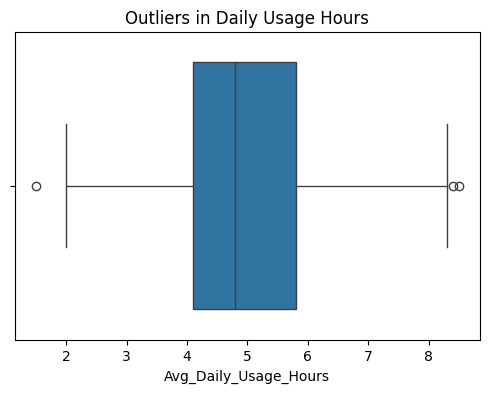

In [19]:
# Detect Outliers in Daily Usage Hours

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Usage_Hours'])
plt.title('Outliers in Daily Usage Hours')
plt.show()

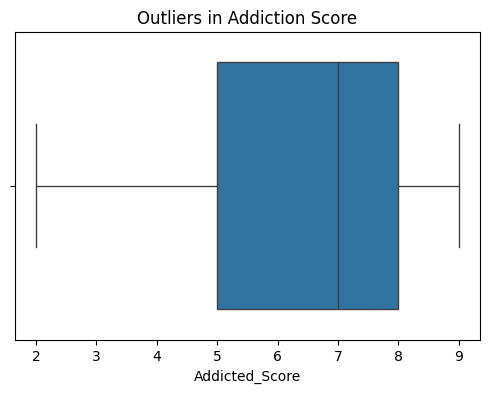

In [20]:
# Detect Outliers in Addiction Score

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Addicted_Score'])
plt.title('Outliers in Addiction Score')
plt.show()

In [21]:


df.groupby('Age')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=False)

,Avg_Daily_Usage_Hours
Age,
18,5.385714
19,5.120245
24,5.046154
21,4.950641
20,4.930303
22,4.676190
23,4.508824


In [22]:


df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=False)

,Addicted_Score
Most_Used_Platform,
Whatsapp,7.462963
Snapchat,7.461538
Tiktok,7.428571
Instagram,6.554217
Youtube,6.100000
Wechat,6.066667
Kakaotalk,6.000000
Facebook,5.666667
Twitter,5.500000


In [25]:
print(df.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score']


In [28]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

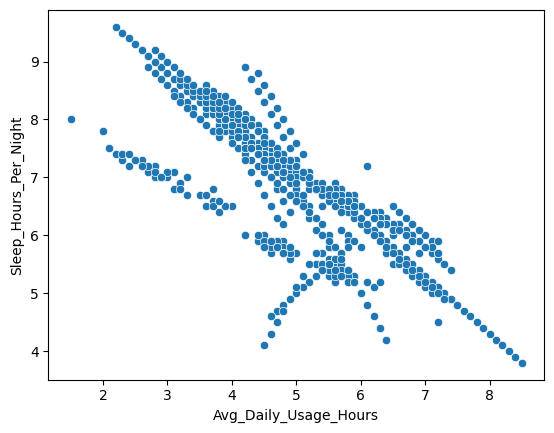

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night')

plt.show()

In [30]:
df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']].corr()

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night
Avg_Daily_Usage_Hours,1.000000,-0.790582
Sleep_Hours_Per_Night,-0.790582,1.000000


In [31]:
df.groupby('Affects_Academic_Performance')['Addicted_Score'].mean()

,Addicted_Score
Affects_Academic_Performance,
No,4.595238
Yes,7.461369


In [32]:
high_risk = df[df['Addicted_Score'] >= 8]

high_risk[['Student_ID', 'Age', 'Most_Used_Platform', 'Addicted_Score']]

,Student_ID,Age,Most_Used_Platform,Addicted_Score
0,1,19,Instagram,8
2,3,20,Tiktok,9
5,6,19,Instagram,9
7,8,20,Snapchat,8
11,12,20,Tiktok,8
...,...,...,...,...
694,695,20,Instagram,8
696,697,21,Tiktok,8
699,700,22,Twitter,8
701,702,23,Instagram,9


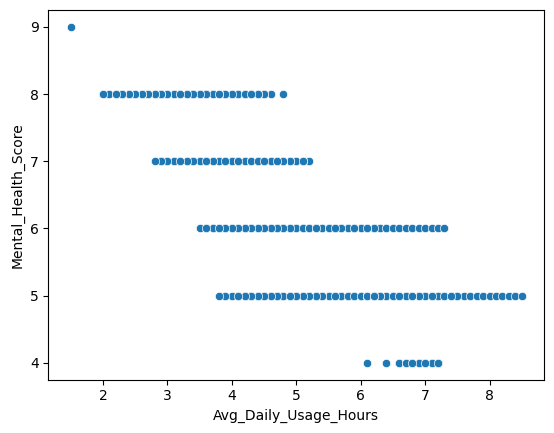

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score')

plt.show()

In [34]:
df[['Avg_Daily_Usage_Hours', 'Mental_Health_Score']].corr()

,Avg_Daily_Usage_Hours,Mental_Health_Score
Avg_Daily_Usage_Hours,1.000000,-0.801058
Mental_Health_Score,-0.801058,1.000000


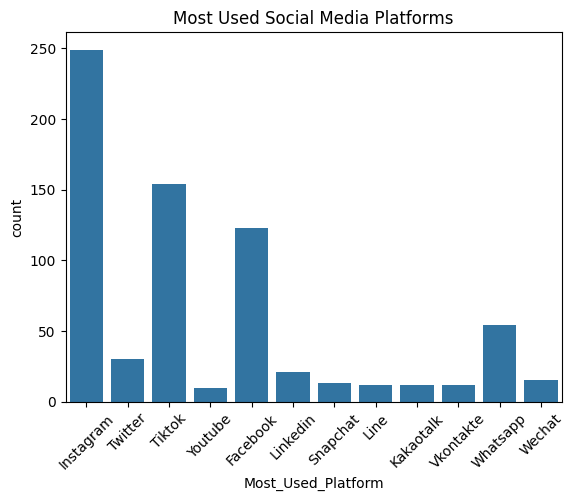

In [35]:
# Bar Chart: Most Used Social Media Platforms

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Most_Used_Platform', data=df)

plt.title('Most Used Social Media Platforms')
plt.xticks(rotation=45)

plt.show()

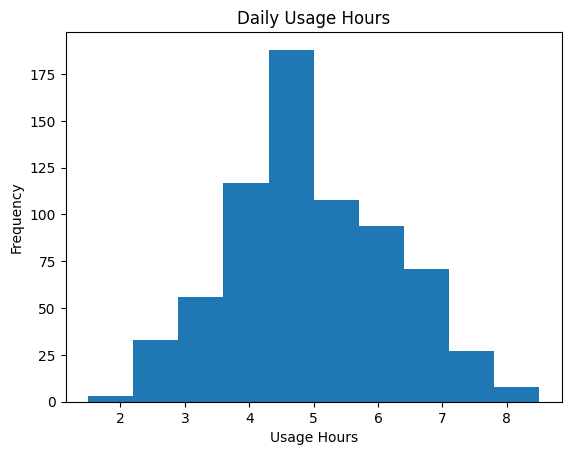

In [36]:
# Histogram: Daily Usage Hours

plt.hist(df['Avg_Daily_Usage_Hours'], bins=10)

plt.title('Daily Usage Hours')
plt.xlabel('Usage Hours')
plt.ylabel('Frequency')

plt.show()

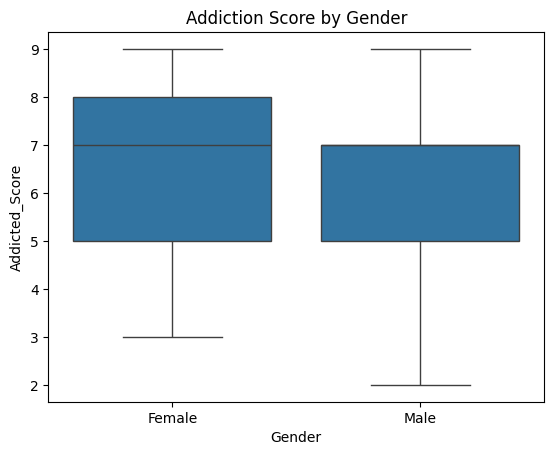

In [37]:
# Boxplot: Addiction Score by Gender

sns.boxplot(x='Gender', y='Addicted_Score', data=df)

plt.title('Addiction Score by Gender')

plt.show()

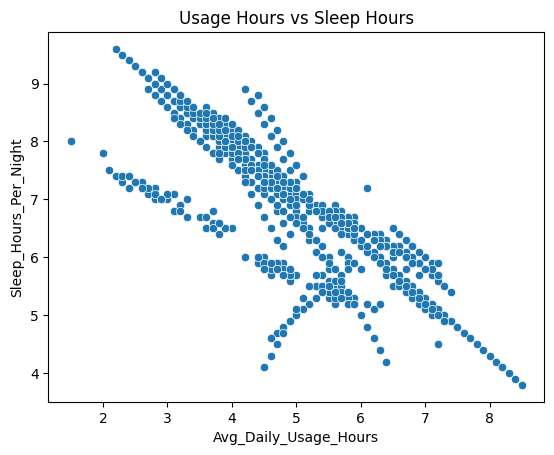

In [38]:
# Scatter Plot: Usage Hours vs Sleep Hours

sns.scatterplot(data=df,
                x='Avg_Daily_Usage_Hours',
                y='Sleep_Hours_Per_Night')

plt.title('Usage Hours vs Sleep Hours')

plt.show()

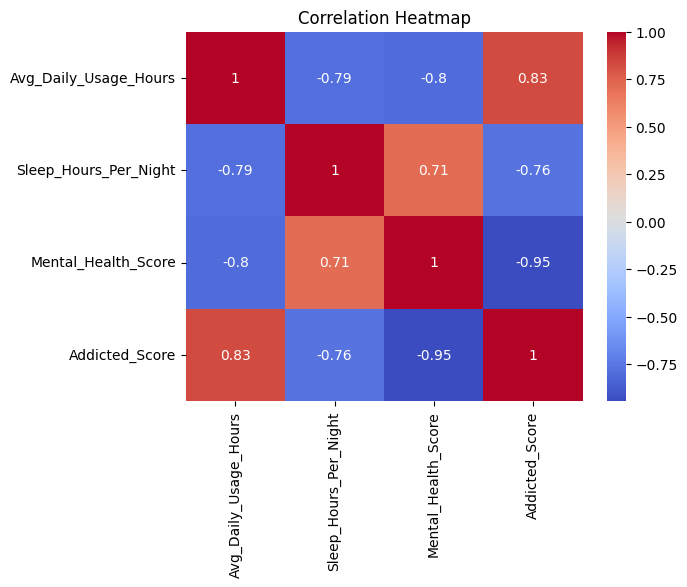

In [39]:
# Heatmap: Correlation

corr_data = df[['Avg_Daily_Usage_Hours',
                'Sleep_Hours_Per_Night',
                'Mental_Health_Score',
                'Addicted_Score']].corr()

sns.heatmap(corr_data, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

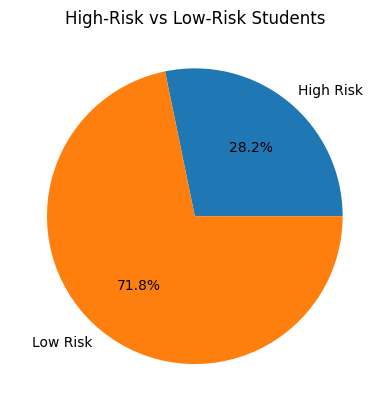

In [40]:
# Pie Chart: High-Risk vs Low-Risk Students

high_risk = df[df['Addicted_Score'] >= 8]
low_risk = df[df['Addicted_Score'] < 8]

sizes = [len(high_risk), len(low_risk)]

labels = ['High Risk', 'Low Risk']

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title('High-Risk vs Low-Risk Students')

plt.show()

In [41]:
# Average Daily Usage Hours

df['Avg_Daily_Usage_Hours'].mean()

np.float64(4.918723404255319)

In [42]:
# Average Addiction Score

df['Addicted_Score'].mean()

np.float64(6.436879432624114)

In [43]:
# Percentage of High-Risk Students

high_risk = df[df['Addicted_Score'] >= 8]

percentage = (len(high_risk) / len(df)) * 100

print(percentage)

28.22695035460993


In [44]:
# Average Sleep Hours

df['Sleep_Hours_Per_Night'].mean()

np.float64(6.868936170212766)

In [45]:
# Most Used Platform

df['Most_Used_Platform'].mode()

,Most_Used_Platform
0,Instagram


In [46]:
# Average Mental Health Score

df['Mental_Health_Score'].mean()

np.float64(6.226950354609929)

In [47]:
df.to_csv('Cleaned_Student_Data.csv', index=False)